Nombre y apellido: Kreszczuk Oscar Mauricio

Carrera: Licenciatura en Ciencia de Datos

Dataset:

[Collab](https://drive.google.com/file/d/1cgeSapWUOwF_swQfS5hZEysAhlYT_LwN/view?usp=sharing)

[Dataset (Drive)](https://drive.google.com/drive/folders/1YR7Ry3eq83NAzL_ecJifLZaFmXFElSAp?usp=sharing)

## Dataset

### **The Simpsons Characters Data**

Este notebook utiliza el dataset de **Los Simpson**, desarrollado y recopilado por **Alex Attia**.

[Kaggle](https://www.kaggle.com/datasets/alexattia/the-simpsons-characters-dataset)

---

### Estructura y Contenido del Dataset

**Imágenes de Entrenamiento (`simpsons_dataset`):** Un volumen total de más de 42,000 imágenes organizadas en directorios por personaje. El dataset base cubre a 20 personajes, con una densidad de entre 400 y 2000 screenshots sacadas directamente de los capitulos.
Aqui se utilizara solamente un subconjunto, centrandonos en 6 personajes.

**Archivo de Anotaciones (`annotation.txt`):** Archivo clave para tareas de localización y regresión de cajas de límites. Contiene las coordenadas espaciales de los personajes presentes en las imágenes con el siguiente formato:

* `x1, y1`: Vértice superior izquierdo de la caja de límites.
* `x2, y2`: Vértice inferior derecho de la caja de límites.

---

### Información de Licencia y Uso

* **Licencia:** CC BY-NC-SA 4.0 (Atribución-NoComercial-CompartirIgual).
---

## Modulos

In [ ]:
import io
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from google.colab import drive
from IPython.display import HTML, display
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model


## Parte 1 — Exploración y análisis del dataset

Para asegurar un aprendizaje correcto y evitar que los modelos desarrollen sesgos hacia los personajes con mayor cantidad de capturas en los episodios, se aplicó una estrategia de balanceo, limitando la cantidad de imágenes a un número equitativo por clase. Luego, este volumen de datos procesado se dividió en dos subconjuntos principales: un conjunto de entrenamiento (Train), que el modelo utiliza para aprender los patrones visuales y ajustar sus pesos internos; y un conjunto de prueba o validación (Test). Este último está compuesto por imágenes que la red nunca vio durante la fase de entrenamiento y se utiliza estrictamente para evaluar la capacidad de generalización del modelo y diagnosticar si sufre overfitting.

In [ ]:
# 1.1 Carga de imágenes

IMG_SIZE = 128
imagenes = []
labels = []
clases = ['homer_simpson', 'bart_simpson', 'lisa_simpson', 'marge_simpson', 'ned_flanders', 'montgomery_burns']

#ruta real
dataset_dir = "../data/simpsons_dataset"
MAX_IMG_PER_CHAR = 300

for clase in clases:
    carpeta = os.path.join(dataset_dir, clase)

    # limita a las indicadas
    archivos = os.listdir(carpeta)[:MAX_IMG_PER_CHAR]

    for archivo in archivos:
        ruta = os.path.join(carpeta, archivo)
        imagen = cv2.imread(ruta)
        if imagen is None:
            continue
        imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
        imagen = cv2.resize(imagen, (IMG_SIZE, IMG_SIZE))
        imagenes.append(imagen)
        labels.append(clases.index(clase))

    print(clase, 'listo')

imagenes = np.array(imagenes)
labels = np.array(labels) # Lo convertimos también para tener las etiquetas listas

print(f"Forma final de imagenes: {imagenes.shape}")

homer_simpson listo
bart_simpson listo
lisa_simpson listo
marge_simpson listo
ned_flanders listo
montgomery_burns listo
Forma final de imagenes: (1800, 128, 128, 3)


Son 6 clases : homer_simpson, bart_simpson, lisa_simpson, marge_simpson, ned_flanders y montgomery_burns. El dataset original estaba desbalanceado en la distribución de capturas por personaje. Por este problema y para evitar que la red  desarrolle un sesgo hacia las clases mayoritarias se establecio un límite máximo de carga de 300 imágenes válidas por personaje.Como resultado de esta etapa de preprocesamiento, el subset definitivo quedó conformado por un volumen efectivo de 1800 imágenes totales, perfectamente balanceadas (300 imágenes $\times$ 6 personajes). Todas las instancias fueron normalizadas espacialmente mediante un reescalado uniforme a una resolución de $128 \times 128$ píxeles con tres canales de color (RGB), consolidando un tensor de entrada final con dimensiones de (1800, 128, 128, 3).

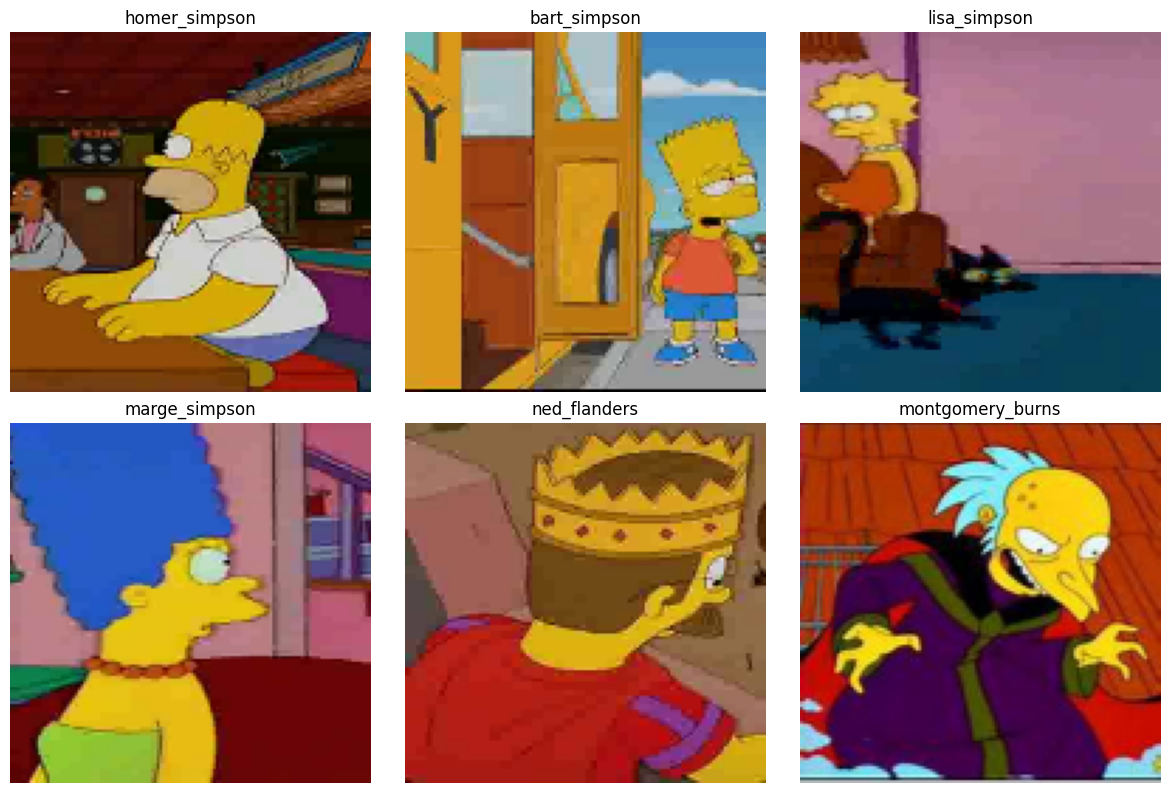

In [ ]:
# 1.2 Ejemplos



plt.figure(figsize=(12, 8))

ejemplos_indices = []
for i in range(len(clases)):
    idx = np.where(labels == i)[0][0]
    ejemplos_indices.append(idx)

# Los 6 personajes
for i in range(len(clases)):
    plt.subplot(2, 3, i + 1)
    idx_imagen = ejemplos_indices[i]
    plt.imshow(imagenes[idx_imagen])
    plt.title(clases[labels[idx_imagen]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 1.3 Información de las imágenes
print('Shape:', imagenes[0].shape)
print('Tipo de dato:', imagenes[0].dtype)
print('Valor mínimo:', imagenes[0].min())
print('Valor máximo:', imagenes[0].max())

Shape: (128, 128, 3)
Tipo de dato: uint8
Valor mínimo: 0
Valor máximo: 246


Exploración

**Personajes:** Los personajes varian espacialmente (perfiles, vistas de tres cuartos y frontales), con variaciones drásticas en sus expresiones faciales y gestos.

**Fondos:** Son fondos complejos y altamente variables. Mientras algunas imágenes contienen planos limpios o desenfocados, otras incorporan elementos en el escenario (como la planta nuclear, el aula de la escuela o la taberna de Moe). Es ruido visual, los modelos tendran que poder "aislar" al personaje (región de interés) del entorno y evitar correlaciones erroneas durante el entrenamiento.

**Reescalado:** Se normalizo  a una resolución de $128 \times 128$ , preserva el alto contraste y las líneas de los bordes características de la animación. Reducio significativamente la carga computacional y la cantidad de parámetros de entrada, pero mantuvo el nivel de detalle necesario para los rasgos clave (el pelo de Lisa, los anteojos de Flanders o la silueta de Burns).

**Conversion Cromática:** Conversión manual a RGB, para asegurar que los canales sigan el estándar para la cual están diseñadas la mayoría de las herrramientas a usar.

**Tonos de piel** Los tonos de piel amarillos en cinco de los personajes dificultarian la clasificación por proximidad cromática, lo que obligaria al modelo a depender de las características espaciales más que de color globales para lograr una separación precisa.

## Parte 2 — Procesamiento Digital de Imágenes

### 2.1 Transformaciones de intensidad

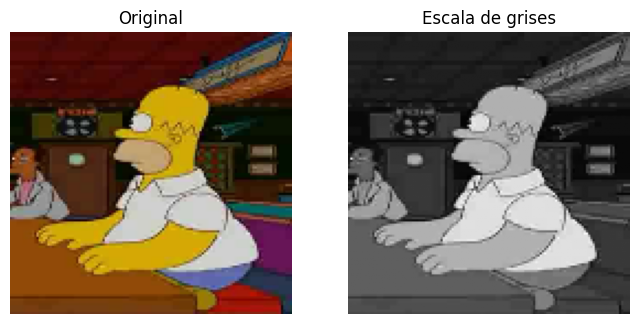

In [ ]:
# Conversión a escala de grises

imagen = imagenes[0]
gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(imagen)
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gris, cmap='gray')
plt.title('Escala de grises')
plt.axis('off')

plt.show()

**Mantiene la estructura:** Al remover los canales de color, se pierde la información del amarillo de la piel y de la paleta de color de los fondos. Sin embargo, visualmente los elementos esenciales (las líneas de contorno negras, forma de los ojos, la silueta del pelo, los cambios de contraste, etc) se preservan intactos. Esto es porque se calculo la intensidad lumínica intrínseca de cada píxel, manteniendo como se definen los bordes.

**Para el modelo:** Para modelos neurales no se recomienda. Al uniformizar los canales de color, personajes con una estructura similar o con fondos homogéneos podrían volverse más difíciles de clasificar, convendria mantener el dataset original en formato RGB para que el modelo use las correlaciones cromáticas junto con las espaciales.

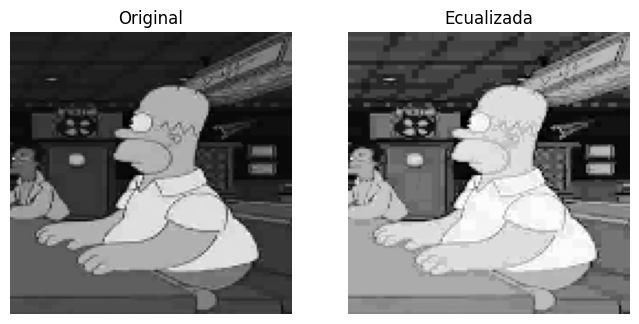

In [ ]:
# Ecualización de histograma

equalizada = cv2.equalizeHist(gris)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(gris, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(equalizada, cmap='gray')
plt.title('Ecualizada')
plt.axis('off')

plt.show()

**Mejoro el contraste:** La imagen original en escala de grises era predominantemente oscura debido al entorno de la taberna; la ecualización estiró el rango, se aclaro notablemente el cuerpo de Homero y aumento el contraste general con respecto al fondo.

**Perdio detalles:** Al forzar los tonos, se genero una pérdida de detalles por saturación en las regiones más claras. Se nota en la camisa blanca de Homero, donde las líneas negras del dibujo original y los pliegues casi desaparecen por completo en el blanco.

**Aumento el ruido:** En las zonas con degradados suaves o fondos oscuros (como el techo), se agruparon los píxeles con niveles de gris cercanos. Genero un efecto de pixelado o "falso contorno" que genera ruido donde antes la información era homogénea.

**Utilidad para preprocesamiento:** Para PDI clásico resulta útil porque ayuda a identificar los elementos de la iluminación original de la captura. Sin embargo, para alimentar modelos (ANN/CNN), suele ser contraproducente, ya que la alteración las texturas e intensidades destruye rasgos clave que la red necesita aprender para generalizar correctamente.



### 2.2 Muestreo y degradación


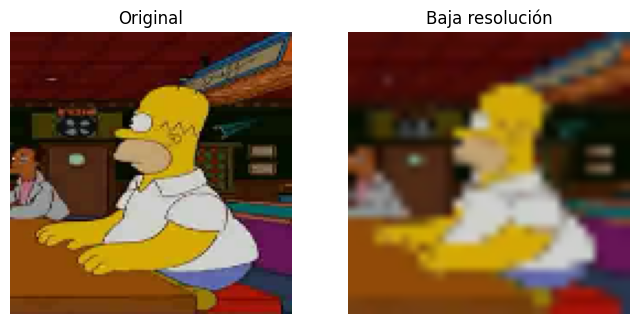

In [ ]:
# Reduccion de resolucion

baja_res = cv2.resize(imagen, (32,32))
baja_res = cv2.resize(baja_res, (128,128))
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(imagen)
plt.title('Original')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(baja_res)
plt.title('Baja resolución')
plt.axis('off')
plt.show()

1. **Submuestreo:** La imagen original de $128 \times 128$ píxeles se reduce  a $32 \times 32$ píxeles.

2. **Sobremuestreo (Interpolación):** Se vuelve a escalar a $128 \times 128$ píxeles mediante interpolación bilineal.

Fenómenos:

* **Pérdida Irreversible de Información:** Al reducir el tamaño se pierden muchos de los píxeles originales. Los detalles que varían espacialmente(como el contorno del personaje, la separación de los dientes o los rasgos pequeños de los ojos) desaparecen por completo. Al realizar el sobremuestreo posterior, la información perdida no se recupera, la reconstrucción es solo una aproximación matemática de los datos que quedaron.

* **Efecto de Blurring:** La imagen reconstrucida se ve suave y borrosa en los bordes. Esto ocurre porque los nuevos píxeles se promedian linealmente de los valores de los vecinos más cercanos. Suaviza la intensidad y elimina la nitidez del dibujo.

* **Aparición de Artefactos de Pixelado:** Las regiones que ya originalmente presentaban curvas suaves (como el contorno de la cabeza o las orejas) ahora tienen deformaciones visuales debido a la falta muestral para representar bien las curvas.

* **Reducir demasiado la resolucion para la red:** Si bien  $32 \times 32$ pixeles reduciría drásticamente el costo computacional de las capas dde una red, la destrucción de los contornos y de los detalles espaciales comprometería gravemente la capacidad del modelo para extraer mapas de características que clasifiquen bien.

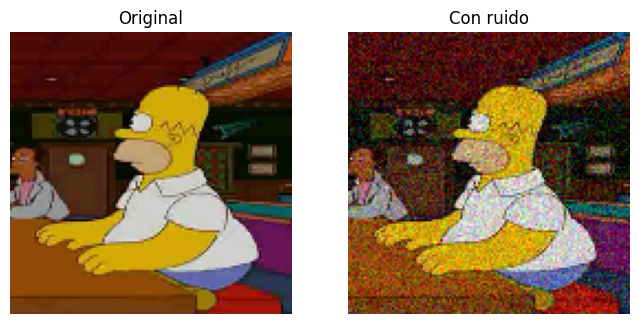

In [ ]:
# Agregado de ruido

ruido = np.random.normal(0,25, imagen.shape)
imagen_ruido = np.clip(imagen.astype(np.float64) + ruido, 0, 255).astype(np.uint8)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(imagen)
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(imagen_ruido)
plt.title('Con ruido')
plt.axis('off')

plt.show()

Se define un ruido gaussiano con media $\mu = 0$ y una desviación estándar $\sigma = 25$. Para simular el ruido en la imagen.

Fenómenos:

* **Granulado:** Esta degradación visualmente queda como un granulado denso distribuido uniformemente por toda la imagen.

* **Contornos:** A pesar de l ruido, los rasgos estructurales de homero (como la silueta del contorno negro o los ojos) siguen siendo identificables a la vista. El ruido no llega a anular por completo los bordes y el contraste del dibujo, aunque sí reduce su nitidez.

### 2.3 Filtrado espacial


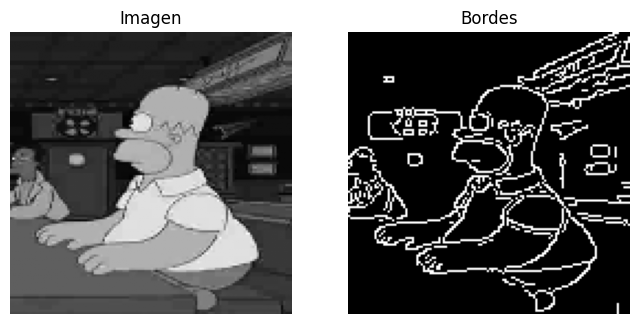

In [ ]:
# Bordes Canny

bordes = cv2.Canny(gris, 100, 200)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(gris, cmap='gray')
plt.title('Imagen')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(bordes, cmap='gray')
plt.title('Bordes')
plt.axis('off')
plt.show()

**Resalto bordes:** El algoritmo resalta los cambios abruptos de intensidad en la imagen. En este caso, aisla perfectamente los contornos al ser personajes dibujados: define nítidamente la silueta de Homero, sus ojos, boca, líneas de la oreja y la separación de su ropa. También captura las líneas del fondo, como los marcos de las ventanas y el billar.

**Para PDI Clasico:** Es una herramienta fundamental porque reduce los datos a procesar, eliminando texturas, colores, etc. Para quedarse únicamente con la forma. Sin embargo, para alimentar una red, pasarle solo los bordes es mala idea, ya que los modelos aprovechan mejor la información cromática (como el color amarillo de la piel) para clasificar con precisión.

**Sensibleal ruido:** Canny es altamente sensible al ruido. Si aplicáramos este filtro directamente sobre la imagen con ruido de la sección anterior, el algoritmo detectaría cada punto de ruido como si fuera un micro-borde, llenando la pantalla de un patrón de puntos blancos inservible. Por eos, es recomendable un suavizado previo antes de calcular los gradientes.

## Parte 3 — Clasificación utilizando Deep Learning


### 3.1 Clasificación utilizando una ANN


In [ ]:
# Preparación de datos
X = imagenes / 255.0
y = labels
X_train, X_test, y_train, y_test = train_test_split(
 X,
 y,
 test_size=0.2, #20% de 300 es 60 imagenes.
 random_state=42,
 stratify=y
)


In [ ]:
#Aplanado de imágenes
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)


In [ ]:
#Modelo ANN
model_ann = keras.Sequential([
 layers.Dense(128, activation='relu',
input_shape=(X_train_flat.shape[1],)),
 layers.Dropout(0.3),
 layers.Dense(64, activation='relu'),
 layers.Dense(len(clases), activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Compilación del modelo
model_ann.compile(
 optimizer='adam',
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy']
)

In [ ]:
#Entrenamiento
history_ann = model_ann.fit(
 X_train_flat,
 y_train,
 epochs=15,
 validation_data=(X_test_flat, y_test)
)


Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.1639 - loss: 1.7918 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.1562 - loss: 1.7919 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.1306 - loss: 1.7919 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.1437 - loss: 1.7919 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.1667 - loss: 1.7919 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.1507 - loss: 1.7919 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.1535 - loss: 1.7919 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.1611 - loss: 1.7919 - val_accuracy: 0.1667 -

In [ ]:
#Evaluaciónloss
acc = model_ann.evaluate(X_test_flat, y_test)
print('Accuracy:', acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1667 - loss: 1.7918
Accuracy: [1.791774868965149, 0.1666666716337204]


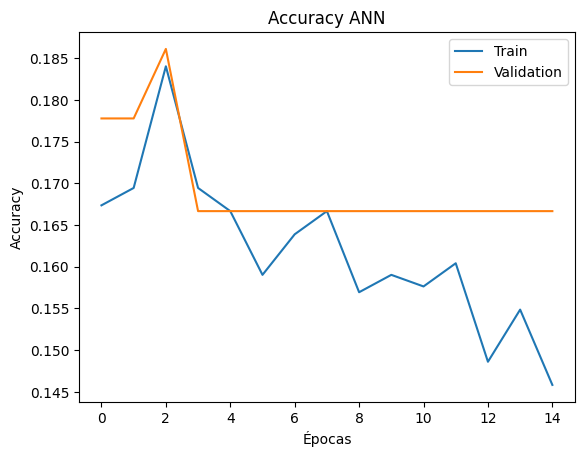

In [ ]:
#Curvas de entrenamiento
plt.plot(history_ann.history['accuracy'])
plt.plot(history_ann.history['val_accuracy'])
plt.title('Accuracy ANN')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


In [ ]:
#Matriz de confusión
predicciones = model_ann.predict(X_test_flat)
predicciones = np.argmax(predicciones, axis=1)
cm = confusion_matrix(y_test, predicciones)
print(cm)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[[60  0  0  0  0  0]
 [60  0  0  0  0  0]
 [60  0  0  0  0  0]
 [60  0  0  0  0  0]
 [60  0  0  0  0  0]
 [59  0  1  0  0  0]]


Con el dataset corregido a 6 clases, se entrenó una red neuronal artificial densa durante 15 épocas, procesando 45 pasos por época en el conjunto de entrenamiento.

**Métricas** El desempeño del modelo fue nulo, en la primera época, la pérdida se estancó en de $1.7918$ tanto para entrenamiento como para validación, manteniéndose congelada de forma idéntica hasta la época 15. La precisión de validación quedó fija en un $16.67\%$ (con apenas variación). Dado que el usamos 6 clases perfectamente equilibradas, una precisión de un sexto ($1/6$) representa exactamente el rendimiento de un clasificador aleatorio; la red no aprendió nada.

**Pérdida de Información Espacial:** El núcleo del problema es el estiramiento  del tensor de entrada a un vector plano. Las capas densas procesan cada uno de los pixeles de manera aislada, ignorando por completo la estructura de la imagen. Al destruir la relación de vecindad entre píxeles, la red pierde la capacidad de conceptualizar contornos, esquinas o texturas. Si una caracteristica (por ejemplo, los ojos de Bart o los anteojos de Flanders) se desplaza unos pocos píxeles debido a un cambio de encuadre o pose, para la capa densa representa un conjunto de entradas completamente nuevo y desvinculado, no lo puede generalizar.

**Underfitting** El estancamiento prematuro de las métricas en valores tan pobres es un síntoma claro de underfitting severo. Ante la incapacidad de procesar el vector aplanado, adam cayó inmediatamente en un mínimo local y el modelo dejó de actualizar sus pesos.

**Validación**: La precisión de validación se planchó en una línea recta horizontal perfecta del ~$0.166\%$. La curva de entrenamiento, por su parte, decae de manera continua por debajo del azar.

**Sesgo Homero**: La matriz de confusión muestra que la red se limitó a predecir sistemáticamente la primera clase de la lista (homer_simpson) para casi todas las muestras del testeo. Esto resultó en 60 aciertos fortuitos para Homero por pura coincidencia estadística, pero un fallo del $100\%$ en Bart, Marge y Flanders. La única excepción fuera de este sesgo fue una sola imagen de Lisa Simpson clasificada erróneamente como Marge.
El modelo falló por completo en reconocer la identidad de 5 de los 6 personajes del dataset.


**CNN**: Lo mejor seria migrar hacia una Red Neuronal Convolucional. Al incorporar capas de convolución y MaxPooling antes del aplanado, el modelo podrá procesar las imágenes conservando su estructura espacial original, extraer mapas de características (bordes, siluetas y combinaciones de color) y explotar la invariancia a la traslación necesaria para reconocer a los personajes sin importar su posición en la screenshot.


### 3.2 Clasificación utilizando una CNN


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Configuración optimizada del Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,               # Margen aumentado para absorber el ruido de validación
    restore_best_weights=True  # Conserva los mejores pesos antes del estancamiento
)

#

#Modelo CNN
model_cnn = keras.Sequential([
 layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE,
IMG_SIZE, 3)),
 layers.MaxPooling2D((2,2)),
 layers.Conv2D(64, (3,3), activation='relu'),
 layers.MaxPooling2D((2,2)),
 layers.Conv2D(128, (3,3), activation='relu'),
 layers.MaxPooling2D((2,2)),
 layers.Flatten(),
 layers.Dense(128, activation='relu'),
 layers.Dropout(0.3),
 layers.Dense(len(clases), activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Compilación
model_cnn.compile(
 optimizer='adam',
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy']
)


In [ ]:
#Entrenamiento
history_cnn = model_cnn.fit(
 X_train,
 y_train,
 epochs=50, #15
 validation_data=(X_test, y_test),
 callbacks=[early_stop]  # <--- EARLY STOPPING
)


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.2639 - loss: 1.8070 - val_accuracy: 0.3667 - val_loss: 1.5760
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.4382 - loss: 1.4162 - val_accuracy: 0.5167 - val_loss: 1.3435
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.5417 - loss: 1.2009 - val_accuracy: 0.5278 - val_loss: 1.2765
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.6583 - loss: 0.9560 - val_accuracy: 0.5944 - val_loss: 1.1718
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7069 - loss: 0.7957 - val_accuracy: 0.5833 - val_loss: 1.2297
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.7625 - loss: 0.6649 - val_accuracy: 0.6028 - val_loss: 1.1139
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8111 - loss: 0.5160 - val_accuracy: 0.5889 - val_loss: 1.3058
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8819 - loss: 0.3602 - val_accuracy: 0.6194 - val_loss:

In [ ]:
# resumen CNN
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,916,244 (37.83 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,610,830 (25.22 MB)

In [ ]:
# ==============================================================================
# Evaluación del Modelo CNN
# ==============================================================================

loss, acc = model_cnn.evaluate(X_test, y_test)
print('Accuracy CNN:', acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step - accuracy: 0.6028 - loss: 1.1139
Accuracy CNN: 0.6027777791023254


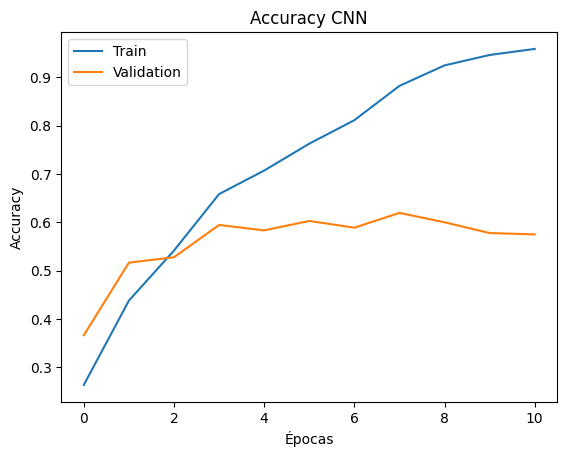

In [ ]:
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title('Accuracy CNN')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


El entrenamieto paró en la época 11 por EarlyStopping. Se implemento porque antes el modelo a partir de un punto se estancaba en overfitting.

El modelo detectó que después de la época 6 (val_loss: 1.1139), la loss validación empezó a empeorar en lugar de mejorar. Por patience=5, esperó 5 épocas exactas (hasta la 11) y al ver que ninguna la superaba, cortó ahí y restauró los pesos de esa mejor época (restore_best_weights=True).

Mucho mejor frente a ANN, esto porque la CNN no destruye la estructura de la imagen aplanandola al inicio. primero pasa por las capas de convolucion que consiguen extraer mapas de características complejas (como bordes, siluetas de pelo y contrastes faciales) y se aplana recién cuando se pasa a las capas densas de clasificación.


**OVERFITTING** Aunque el early stopping evitó que empeorara, sigue habiendo overfitting. El gráfico de Accuracy muestra una distancia creciente entre ambas curvas a partir de la 2-3 época. Mientras la curva de entrenamiento mantiene una pendiente ascendente firme, la curva de validación tiende a estancarse. Entonces la red puede memorizar las caracteristicas de las imagenes de entrenamiento como ruido, iluminación y fondos específicos, pero pierde efectividad a la hora de generalizar ante muestras no vistas en la validación.

## Parte 4 — Aplicaciones modernas

En vez de aplicar metodos para tratar de mejorar el modelo CNN anterior, se intenta realizar transfer learning. De esa forma en vez de entrenar capas de convolucion para extraer caracteristicas utilizo unas que ya estan entrenadas y congelo sus parametros.

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
 input_shape=(IMG_SIZE, IMG_SIZE, 3),
 include_top=False,
 weights='imagenet'
)
base_model.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
#Construcción del modelo
model_tl = keras.Sequential([
 base_model,
 layers.GlobalAveragePooling2D(),
 layers.Dense(128, activation='relu'),
 layers.Dropout(0.3),
 layers.Dense(len(clases), activation='softmax')
])


In [ ]:
#Compilación
model_tl.compile(
 optimizer='adam',
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy']
)


In [ ]:
#Entrenamiento
history_tl = model_tl.fit(
 X_train,
 y_train,
 epochs=10,
 validation_data=(X_test, y_test)
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 529ms/step - accuracy: 0.4521 - loss: 1.4724 - val_accuracy: 0.6111 - val_loss: 1.0399
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 25s 550ms/step - accuracy: 0.6972 - loss: 0.8606 - val_accuracy: 0.6528 - val_loss: 0.9178
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 484ms/step - accuracy: 0.7951 - loss: 0.5926 - val_accuracy: 0.7306 - val_loss: 0.7869
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 531ms/step - accuracy: 0.8542 - loss: 0.4541 - val_accuracy: 0.7222 - val_loss: 0.8240
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 523ms/step - accuracy: 0.8778 - loss: 0.3529 - val_accuracy: 0.7417 - val_loss: 0.7803
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 504ms/step - accuracy: 0.9139 - loss: 0.2938 - val_accuracy: 0.7528 - val_loss: 0.7690
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 524ms/step - accuracy: 0.9396 - loss: 0.2159 - val_accuracy: 0.7417 - val_loss: 0.8080
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 519ms/step - accuracy: 0.9604 - loss: 0.1671 - val_accu

In [ ]:
loss, acc = model_tl.evaluate(X_test, y_test)
print('Accuracy Transfer Learning:', acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 385ms/step - accuracy: 0.7444 - loss: 0.7957
Accuracy Transfer Learning: 0.7444444298744202


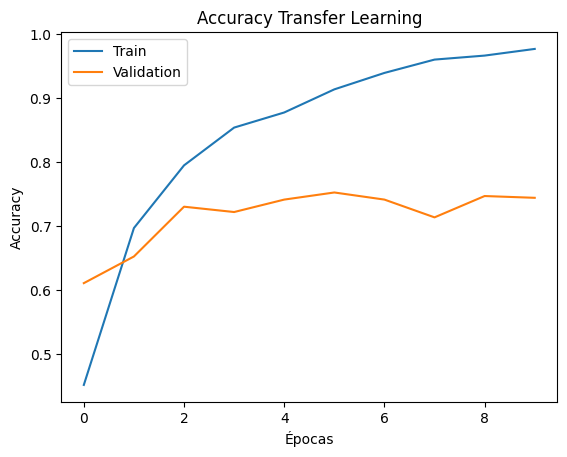

In [ ]:
plt.plot(history_tl.history['accuracy'])
plt.plot(history_tl.history['val_accuracy'])
plt.title('Accuracy Transfer Learning')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
#Matriz de confusión CNN
predicciones_cnn = model_cnn.predict(X_test)
predicciones_cnn = np.argmax(predicciones_cnn, axis=1)
cm_cnn = confusion_matrix(y_test, predicciones_cnn)
print(cm_cnn)

print("-" * 50)

#Matriz de confusión Tl
predicciones = model_tl.predict(X_test)
predicciones = np.argmax(predicciones, axis=1)
cm = confusion_matrix(y_test, predicciones)
print(cm)

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 383ms/step
[[35  1  7  4  5  8]
 [ 4 26 16  3  7  4]
 [ 7 11 27  4  6  5]
 [ 5  3  5 41  4  2]
 [ 7  2  3  1 45  2]
 [ 4  2  3  2  6 43]]
--------------------------------------------------
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 314ms/step
[[39  2  7  4  5  3]
 [ 4 44  1  7  4  0]
 [ 0  4 49  1  0  6]
 [ 2  4  4 43  5  2]
 [ 3  4  2  4 40  7]
 [ 2  2  3  0  0 53]]


A diferencia de la CNN, MobileNetV2 se entrenó de forma fija durante 10 épocas completas sin detenerse antes. El modelo es estable: la precisión de entrenamiento arrancó en $45.21\%$ y progresó hasta un $97.71\%$ en la décima época. En el conjunto de validación, se mostro mucho mejor con un accuracy máximo de $75\%$ en la época 6 y estabilizándose en un $74\%$ hacia el final.

Si bien persiste algo de overfitting entre las curvas de entrenamiento y validación (Seguramente por no ser una cantidad de muestras suficientes), el modelo es robusto. La pérdida de validación de MobileNetV2 fallo como con la CNN, sino que se mantuvo estable en una franja baja de $0.76 - 0.85$, indicando que generaliza mejor.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


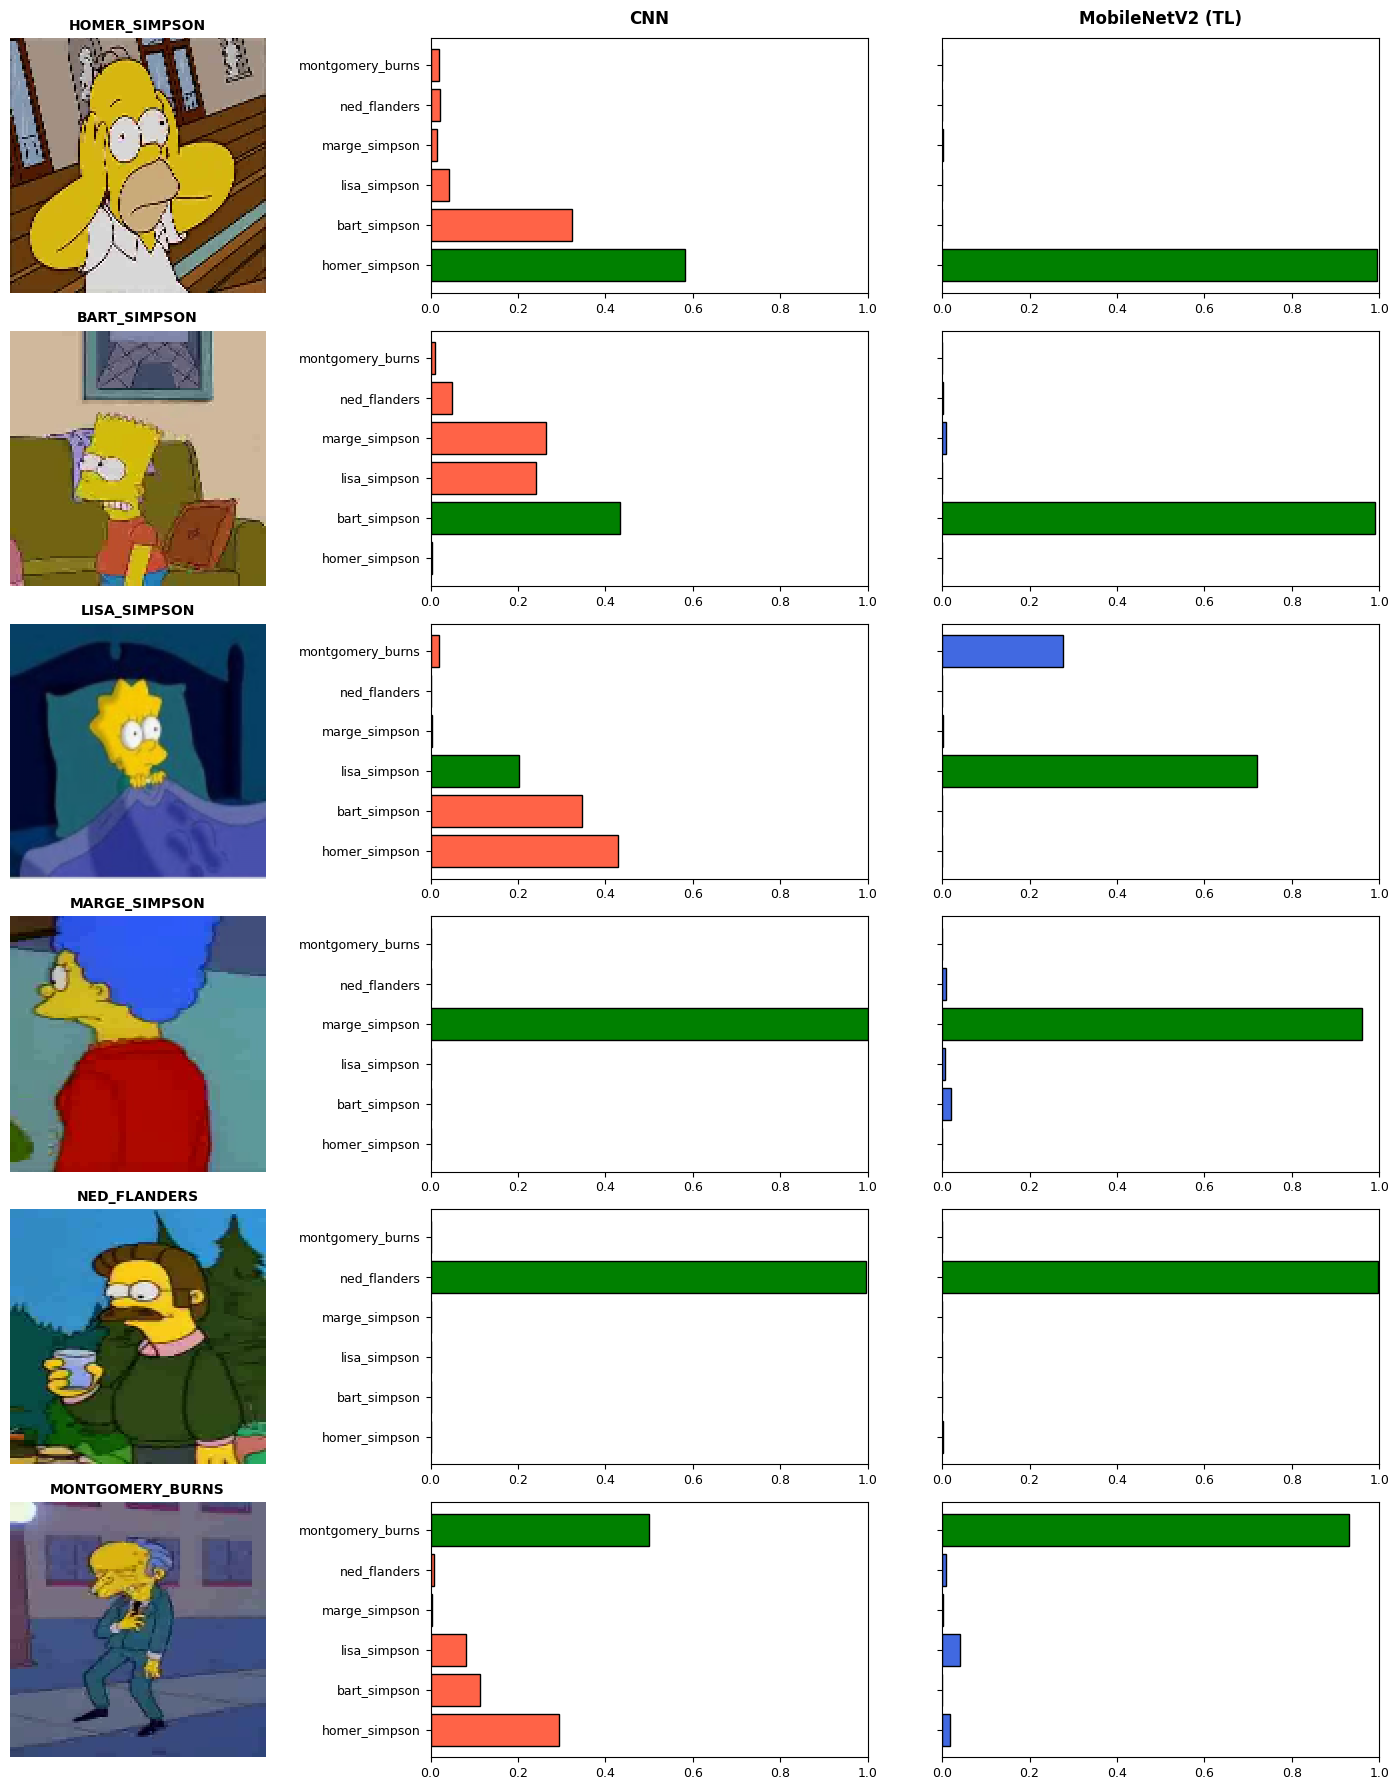

In [ ]:
## Grafico una imagen de cada clase junto con sus probabilidades de cada modelo

fig, axes = plt.subplots(6, 3, figsize=(15, 18))

for i, clase_nombre in enumerate(clases):
    # agarra imagenes
    indices_de_esta_clase = np.where(y_test == i)[0]
    idx_imagen = indices_de_esta_clase[35]

    imagen_test = X_test[idx_imagen]
    etiqueta_real = y_test[idx_imagen]


    imagen_batch = np.expand_dims(imagen_test, axis=0)

    # Obtener predicciones de ambos modelos
    probabilidades_cnn = model_cnn.predict(imagen_batch)[0]
    probabilidades_tl = model_tl.predict(imagen_batch)[0]


    # subplots
    ax_img = axes[i, 0]
    ax_cnn = axes[i, 1]
    ax_tl  = axes[i, 2]

    ####################################################################################
    #Mostrar Imagen
    ax_img.imshow(imagen_test)
    ax_img.set_title(f"{clase_nombre.upper()}", fontsize=10, weight='bold')
    ax_img.axis('off')

    ####################################################################################
    #Barras CNN Propia
    bars_cnn = ax_cnn.barh(clases, probabilidades_cnn, color='tomato', edgecolor='black')
    ax_cnn.set_xlim(0, 1.0)
    ax_cnn.tick_params(axis='both', labelsize=9)
    # Pintar de verde la barra que debió ser correcta
    bars_cnn[etiqueta_real].set_color('green')
    bars_cnn[etiqueta_real].set_edgecolor('black')

    # Titulos
    if i == 0:
        ax_cnn.set_title('CNN', fontsize=12, weight='bold', pad=10)

    ####################################################################################
    #Barras Transfer Learning
    bars_tl = ax_tl.barh(clases, probabilidades_tl, color='royalblue', edgecolor='black')
    ax_tl.set_xlim(0, 1.0)
    ax_tl.set_yticklabels([]) # Ocultamos nombres de clases acá para no duplicar
    ax_tl.tick_params(axis='x', labelsize=9)
    # Pintar de verde la barra que debió ser correcta
    bars_tl[etiqueta_real].set_color('green')
    bars_tl[etiqueta_real].set_edgecolor('black')

    if i == 0:
        ax_tl.set_title('MobileNetV2 (TL)', fontsize=12, weight='bold', pad=10)

plt.tight_layout()
plt.show()

**Bart Simpson**:
Bart está sentado de perfil con un sillón y cuadro de fondo. El color del sillón y el cuadro distraen a la CNN, que confunde a bart con Marge y Lisa. MobileNetV2 habra logrado reconocer los patrones de Bart (como las puntas del pelo o la silueta de los ojos) de forma invariante a la posición y al entorno.

La CNN acierta con apenas un ~43% de confianza, mostrando dudando con Marge y Lisa,mienras que MobileNetV2 Vuelve a clavar un 100% de confianza.


**Lisa Simpson**:
Es un escenario complicado (Lisa en la cama con iluminación azulada y un fondo oscuro). Para el CNN, la paleta cromática lo confunde con Bart. MobileNetV2 logra sobreponerse aun quizas por los colores le hacen asignar una probabilidad secundaria a el Sr. Burns.

La CNN falla, se confunde por completo y clasifica la imagen como homero, dejando a Lisa en tercer lugar. MobileNetV2 acierta con un sólido 65% de confianza, aunque muestra una duda secundaria con el Burns.


**Montgomery Burns**:
El Sr. Burns está encorvado, sosteniendo su pecho con una casa con ventanas y un camino de fondo, durante la noche. Una postura poco comun que quizas confundo al cnn con los niños (Bart/Lisa).

La CNN acierta, dudando con Bart, Homero y Lisa, a punto de fallar. MobileNetV2 resuelve el problema con un contundente más del 90% de confianza.



## DETECCION


Queriendo implementar deteccion se intento utilizar modelos ya entrenados para realizarla junto con mobileNET. Sin embargo los resultados no resultaron convincentes y recordando que el dataset contaba con un archivo annotations.txt que contaba con las coordenadas de las boxes para la deteccion de todas las imagenes, se genero la idea de entrenar la parte de deteccion con ellas junto con las de clasificación.

Usando como extractor de características común la base congelada de MobileNetV2. Tras una capa de Pooling que comprime los mapas de características espaciales en un vector, la arquitectura se bifurca en dos ramas independientes:

**Rama de Clasificación**: Igual que anteriormente, esta compuesta por una capa densa con activación ReLU y una capa de salida con activación Softmax que calcula la distribución de probabilidad sobre las 6 clases.

**Rama de Regresión**: Diseñada específicamente para localizar al personaje de la screenshot, mediante capas densas (con activación ReLU) que culmina en una capa de salida de 4 neuronas con activación sigmoide (las 4 coordenadas para formas la caja).

Dado que hay dos ramas, hubo que definir una nueva función de perdida. Para la clasificación se utilizó la Sparse Categorical Crossentropy (La función toma el entero de la clase, mira qué tan alta o baja fue la probabilidad que el modelo le asignó a esa clase específica, y calcula el logaritmo negativo. Durante el entrenamiento, el optimizador usará el gradiente de esta pérdida para ajustar los pesos del modelo, forzándolo a que esa probabilidad se acerque lo más posible a 1), mientras que para la regresión de las cajas se implementó el MSE (mide la distancia entre las cuatro coordenadas de la caja predicha y la real, calculando el promedio de sus diferencias al cuadrado).

Debido a que las magnitudes de error y las velocidades de convergencia de ambas ramas son diferentes, se configuró un esquema de pesos ponderados (loss_weights):

$$\text{Loss}_{\text{Total}} = 1.0 \times \text{Loss}_{\text{Clase}} + 2.0 \times \text{Loss}_{\text{Caja}}$$

Se le asignó más peso a la rama de detección debido a que aprender las coordenadas espaciales para las cajas representa una tarea de optimización más compleja que la clasificación, que ya se encuentra fuertemente respaldada por los pesos preentrenados de MobileNetV2. El entrenamiento se reguló dinámicamente mediante Early Stopping con una paciencia de 4 épocas para detener el proceso en el instante exacto en que la pérdida combinada de validación dejara de minimizar.

In [ ]:
## PREPARACIÓN
X_det = []
y_clases_det = []
y_cajas_det = []
conteo_clases = {c: 0 for c in clases}

annotation_file = "../data/annotation.txt"

with open(annotation_file, 'r') as f:
    lineas = f.readlines()

errores_ruta = 0

for linea in lineas:
    partes = linea.strip().split(',')
    if len(partes) < 6:
        continue

    ruta_relativa, xmin_str, ymin_str, xmax_str, ymax_str, clase_sucia = partes[:6]

    xmin = int(xmin_str)
    ymin = int(ymin_str)
    xmax = int(xmax_str)
    ymax = int(ymax_str)
    clase = clase_sucia.strip()

    # Homologación de nombres de clases
    if clase == 'charles_montgomery_burns':
        clase = 'montgomery_burns'

    if clase in clases and conteo_clases.get(clase, 0) < MAX_IMG_PER_CHAR:
        nombre_archivo = os.path.basename(ruta_relativa)
        ruta_img = os.path.join(dataset_dir, clase, nombre_archivo)

        if not os.path.exists(ruta_img):
            errores_ruta += 1
            if errores_ruta == 1:
                print(f"DEBUG - Ejemplo de ruta NO encontrada: {ruta_img}")
            continue

        img = cv2.imread(ruta_img)
        if img is None:
            continue

        '''
        Dado que las imágenes del dataset original poseen resoluciones heterogéneas,
        las coordenadas absolutas (x_min, y_min, x_max, y_max) se dividieron por el ancho
        y el alto nativos de cada imagen
        '''
        # A. Normalización de las cajas (Bounding Boxes)
        alto_orig, ancho_orig, _ = img.shape
        xmin_norm = xmin / ancho_orig
        ymin_norm = ymin / alto_orig
        xmax_norm = xmax / ancho_orig
        ymax_norm = ymax / alto_orig

        # B. Preprocesamiento de la imagen
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        X_det.append(img)
        y_clases_det.append(clases.index(clase))
        y_cajas_det.append([xmin_norm, ymin_norm, xmax_norm, ymax_norm])

        conteo_clases[clase] += 1

X_det = np.array(X_det)
y_clases_det = np.array(y_clases_det)
y_cajas_det = np.array(y_cajas_det)

print(f"Carga completa. Total de imágenes procesadas con éxito: {X_det.shape}")
if errores_ruta > 0:
    print(f"Alerta: No se encontraron {errores_ruta} rutas de imágenes.")

# Division de conjuntos
X_train_d, X_test_d, y_clases_train, y_clases_test, y_cajas_train, y_cajas_test = train_test_split(
    X_det, y_clases_det, y_cajas_det, test_size=0.2, random_state=42, stratify=y_clases_det
)

Carga completa. Total de imágenes procesadas con éxito: (1800, 128, 128, 3)


In [ ]:
## MODELADO

# Arquitectura Multi-Salida (MobileNetV2)
base_model_det = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model_det.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model_det(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)

# Rama Clasificación
rama_clase = layers.Dense(128, activation='relu')(x)
rama_clase = layers.Dropout(0.3)(rama_clase)
salida_clase = layers.Dense(len(clases), activation='softmax', name='clase_output')(rama_clase)

# Rama Cajas
rama_caja = layers.Dense(64, activation='relu')(x)
rama_caja = layers.Dense(32, activation='relu')(rama_caja)
salida_caja = layers.Dense(4, activation='sigmoid', name='caja_output')(rama_caja)

# Modelo
modelo_deteccion = tf.keras.Model(inputs=inputs, outputs=[salida_clase, salida_caja])

modelo_deteccion.compile(
    optimizer='adam',
    loss={
        'clase_output': 'sparse_categorical_crossentropy',
        'caja_output': 'mse'
    },
    metrics={
        'clase_output': ['accuracy'],
        'caja_output': ['mse']
    },
    loss_weights={'clase_output': 1.0, 'caja_output': 2.0}
)

# EarlyStopping
callback_det = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history_det = modelo_deteccion.fit(
    X_train_d,
    {
        'clase_output': y_clases_train,
        'caja_output': y_cajas_train
    },
    validation_data=(
        X_test_d,
        {
            'clase_output': y_clases_test,
            'caja_output': y_cajas_test
        }
    ),
    epochs=50,
    callbacks=[callback_det]
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 34s 590ms/step - caja_output_loss: 0.0309 - caja_output_mse: 0.0309 - clase_output_accuracy: 0.3812 - clase_output_loss: 1.6734 - loss: 1.7352 - val_caja_output_loss: 0.0191 - val_caja_output_mse: 0.0191 - val_clase_output_accuracy: 0.6556 - val_clase_output_loss: 1.0244 - val_loss: 1.0677
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 42s 622ms/step - caja_output_loss: 0.0186 - caja_output_mse: 0.0186 - clase_output_accuracy: 0.6826 - clase_output_loss: 0.8818 - loss: 0.9190 - val_caja_output_loss: 0.0182 - val_caja_output_mse: 0.0182 - val_clase_output_accuracy: 0.7583 - val_clase_output_loss: 0.7887 - val_loss: 0.8337
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 506ms/step - caja_output_loss: 0.0154 - caja_output_mse: 0.0154 - clase_output_accuracy: 0.7812 - clase_output_loss: 0.6537 - loss: 0.6845 - val_caja_output_loss: 0.0173 - val_caja_output_mse: 0.0175 - val_clase_output_accuracy: 0.7361 - val_clase_output_loss: 0.7454 - val_loss: 0.7832
Epoch 4/50
45

El entrenamiento concluyó de manera prematura en la época 10, determinando que el punto de convergencia óptima ocurrió en la época 6.

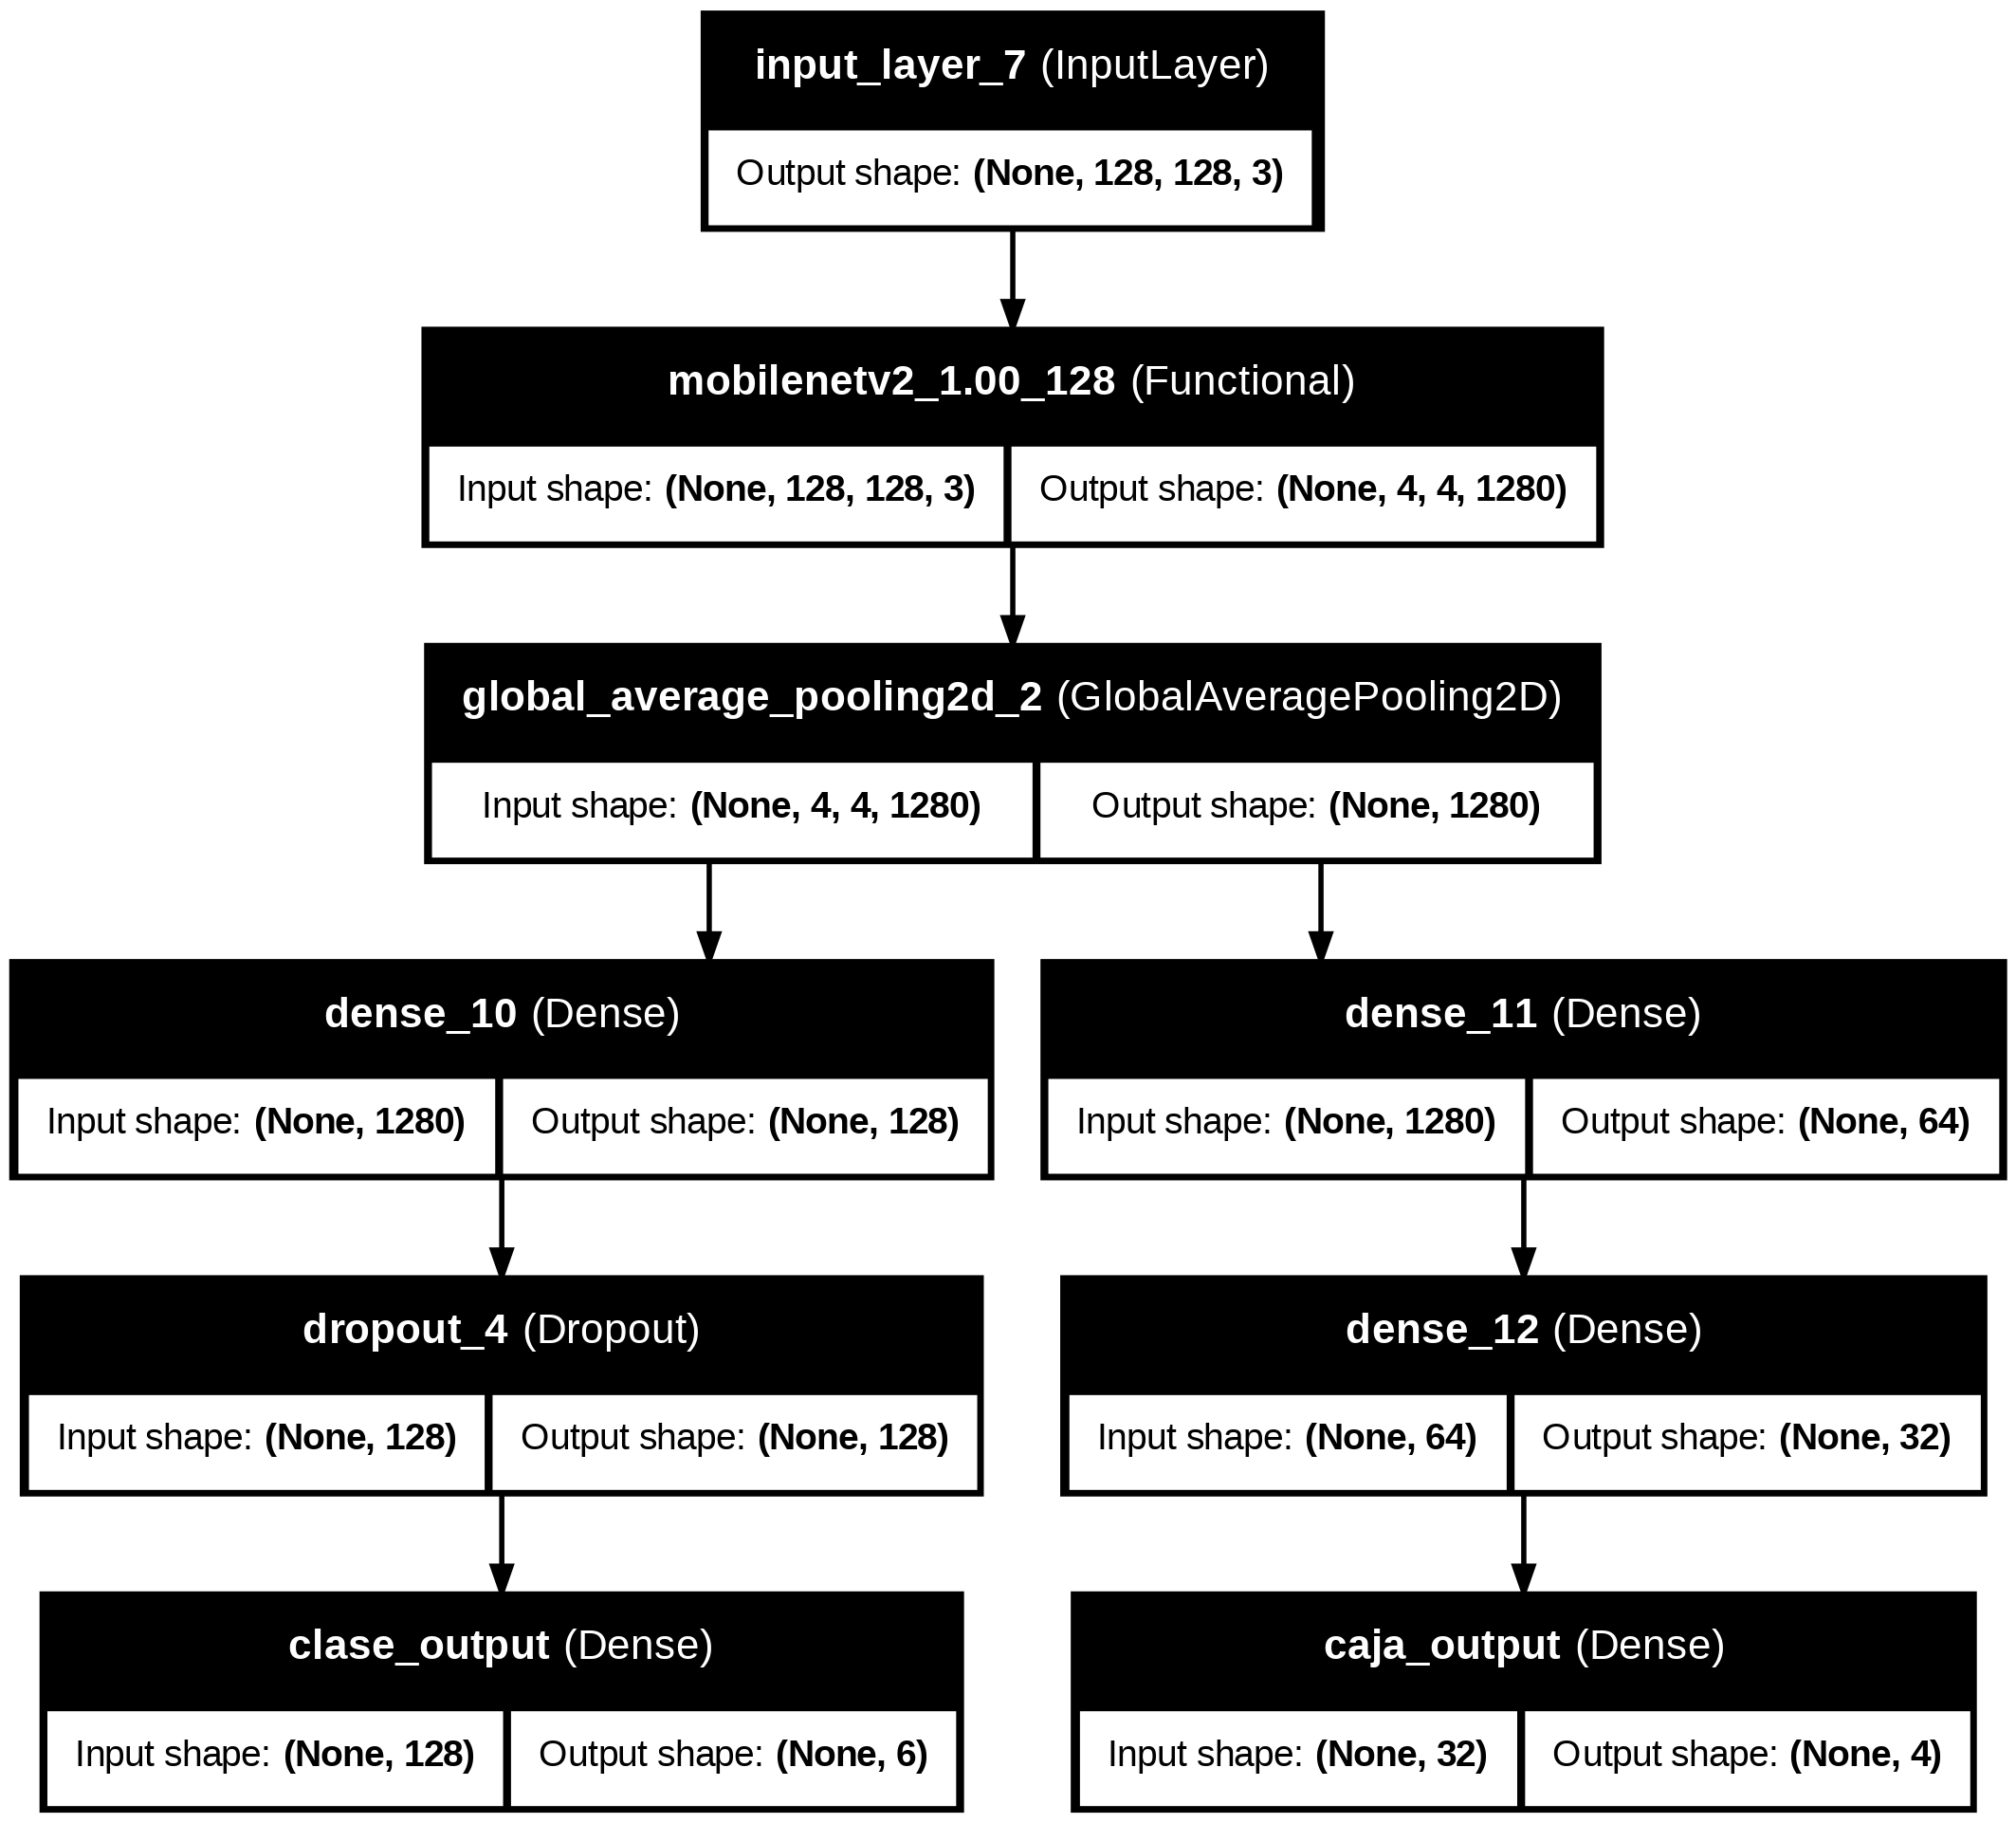

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ input_layer_7[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │     81,984 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │      2,080 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clase_output        │ (None, 6)         │        774 │ dropout_4[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caja_output (Dense) │ (None, 4)         │        132 │ dense_12[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,004,800 (11.46 MB)

 Trainable params: 248,938 (972.41 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 497,878 (1.90 MB)

In [ ]:
# Visualizar el modelo
plot_model(
    modelo_deteccion,
    to_file='modelo_deteccion.png',
    show_shapes=True,
    show_layer_names=True
)

from IPython.display import display, Image
# Alejar la imagen
display(Image('modelo_deteccion.png', width=600))

modelo_deteccion.summary()

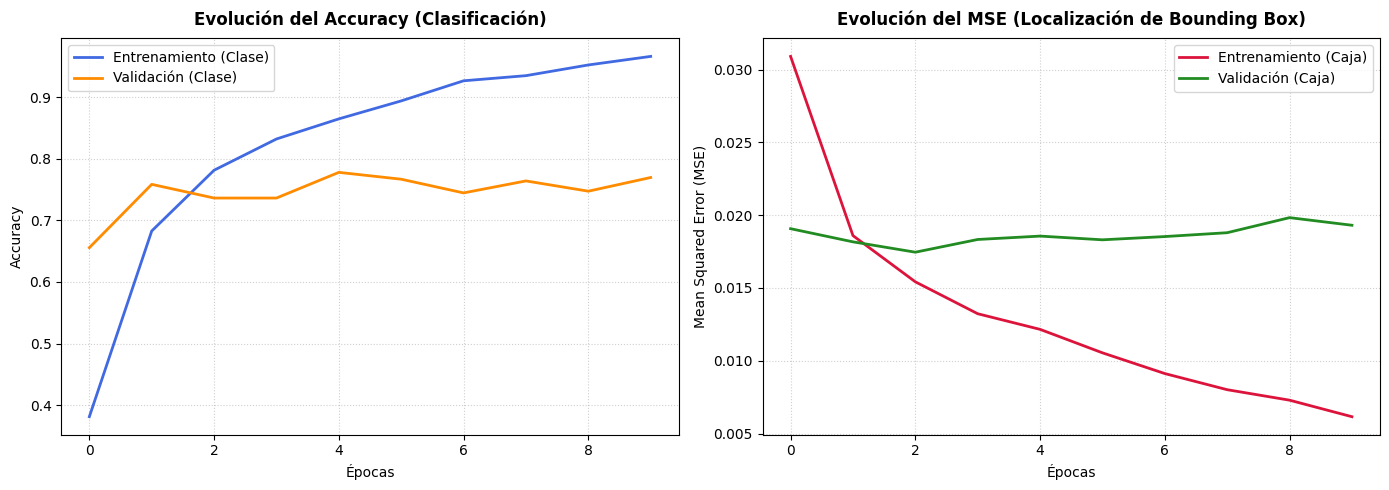

In [ ]:
# Dos subplots en paralelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Accuracy de la Rama de Clasificación
ax1.plot(history_det.history['clase_output_accuracy'], label='Entrenamiento (Clase)', color='royalblue', linewidth=2)
ax1.plot(history_det.history['val_clase_output_accuracy'], label='Validación (Clase)', color='darkorange', linewidth=2)
ax1.set_title('Evolución del Accuracy (Clasificación)', fontsize=12, weight='bold', pad=10)
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Gráfico 2: MSE de la Rama de Regresión (Cajas)
ax2.plot(history_det.history['caja_output_mse'], label='Entrenamiento (Caja)', color='crimson', linewidth=2)
ax2.plot(history_det.history['val_caja_output_mse'], label='Validación (Caja)', color='forestgreen', linewidth=2)
ax2.set_title('Evolución del MSE (Localización de Bounding Box)', fontsize=12, weight='bold', pad=10)
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Mean Squared Error (MSE)')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Precisión**

Se nota clarísimo cómo la validación arranca muy arriba (65\%) en la época 0, por MobileNetV2.
Al igual que pasaba con la CNN original, a partir de la época 2 las curvas divergen. Mientras el entrenamiento roza la perfección, la validación se estanca oscilando entre el 73% y el 77%. Todavía Hay algo de sobreajuste, pero se mantiene en niveles de precisión mucho más aceptables que antes.


**MSE**

En las épocas 0 y 1, el MSE de validación es más bajo que el de entrenamiento. Esto pasa porque la rama de regresión de la caja es muy simple, y al principio del entrenamiento se apoya directamente de las características generales de MobileNetV2.
A partir de la época 2, la curva de entrenamiento cruza y sigue bajando linealmente hasta casi el suelo. Pero la curva de validación se mantiene plana y estable alrededor de 0.018. Osea que logro generalizar bien.

In [ ]:
import matplotlib.patches as patches
def graficar_todos(id_todos):
    """
    Busca la id de cada clase en el conjunto de testeo
    y grafica los resultados en una grilla de 2x3.
    """
    # 2 filas x 3 columnas
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()

    for i, clase_nombre in enumerate(clases):
        # 1. Buscar todos los índices
        indices_clase = np.where(y_clases_test == i)[0]

        idx_clase = indices_clase[id_todos]

        img_prueba = X_test[idx_clase]
        etiqueta_real = clases[y_clases_test[idx_clase]]

        # 2. Predicción
        img_input = np.expand_dims(img_prueba, axis=0)
        pred_clase, pred_caja = modelo_deteccion.predict(img_input, verbose=0)

        # 3. Clasificación
        pred_clase_plana = pred_clase.flatten()
        clase_predicha = clases[np.argmax(pred_clase_plana)]
        confianza = np.max(pred_clase_plana) * 100

        # 4. Coordenadas
        xmin_norm, ymin_norm, xmax_norm, ymax_norm = pred_caja.flatten()
        xmin, ymin = xmin_norm * IMG_SIZE, ymin_norm * IMG_SIZE
        xmax, ymax = xmax_norm * IMG_SIZE, ymax_norm * IMG_SIZE

        # 5. Imagen
        ax = axes[i]
        ax.imshow(img_prueba)

        # Box
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2.5, edgecolor='#00FF00', facecolor='none'
        )
        ax.add_patch(rect)

        # Etiqueta nombres
        texto = f" {clase_predicha.replace('_', ' ').title()} ({confianza:.1f}%) "
        ax.text(
            xmin, ymin - 5, texto, color='black', fontsize=9, fontweight='bold',
            bbox=dict(facecolor='#00FF00', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.2')
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()

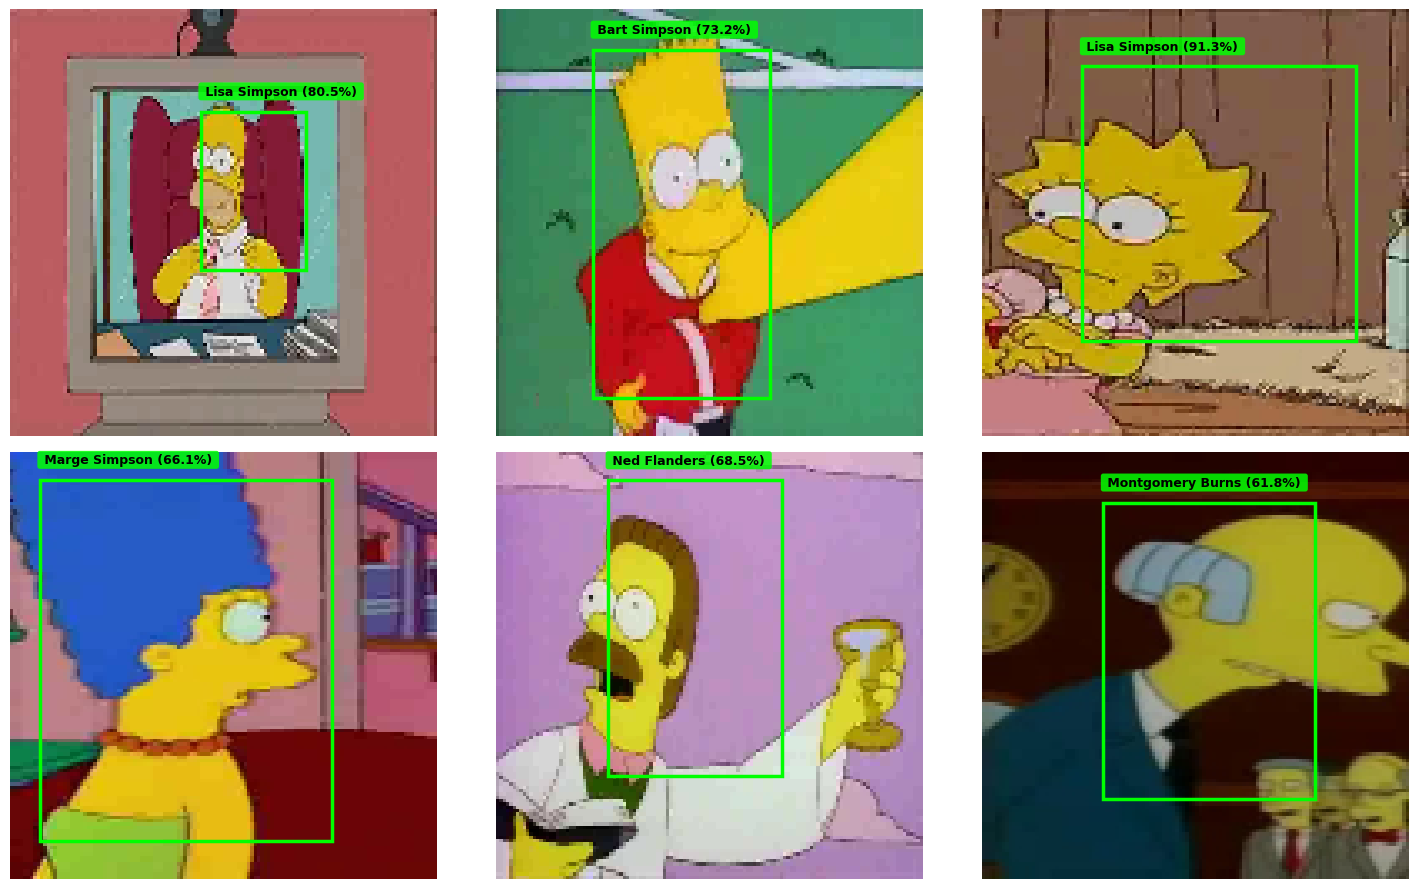

In [ ]:
graficar_todos(50)

Quisieramos saber si obligar al modelo a detectar la ubicación del personaje ayuda o perjudica a la clasificación, enfrentamos a los dos modelos sobre el mismo conjunto de prueba (test).

Probamos los dos modelos con todas las imágenes de prueba, contamos en cuántas acertaron y comparamos el porcentaje de respuestas correctas de cada uno.

In [ ]:
# 1. Calcular accuracy de cada modelo
acc_puro = np.mean(np.argmax(model_tl.predict(X_test_d, verbose=0), axis=1) == y_clases_test)
acc_multi = np.mean(np.argmax(modelo_deteccion.predict(X_test_d, verbose=0)[0], axis=1) == y_clases_test)

print(f"Puro: {acc_puro*100:.2f}% | Con detección: {acc_multi*100:.2f}%")


Puro: 80.83% | Con detección: 76.67%


Al mirar el promedio general, el modelo puro ganó.
Puede ser que al obligar al modelo a resolver dos tareas en simultáneo, se generó una competencia por los recursos. Ademas que ya habiamos definido darle mas prioridad a la detección.

## Conclusiones Finales


### Preparación de los datos

**Balanceo:** Como el dataset original traía más fotos de unos personajes que de otros, se limitó la carga a 300 imágenes por personaje (asi todos tendrian la misma cantidad). Así nos quedó un conjunto simétrico de 1800 imágenes en total, lo que evita que los modelos aprendan el sesgo a personajes con más imagenes.

**Particiones (Train/Test):** El total se dividió en un **80% para entrenar** (1440 imágenes) y un **20% para testeo** (360 imágenes). Usaamos `stratify=y` para garantizar que ese porcentaje se respete por igual para los 6 personajes en ambos bloques.

**Anotaciones:** Para entrenar la detección, leímos las coordenadas de `annotation.txt`. Como las capturas vienen en tamaños diversos, dividimos cada coordenada ($x_1, y_1, x_2, y_2$) por el ancho y alto real de su imagen. Pasarlas a al rango $[0, 1]$ asegura que la resolucion de cada imagen no afecte como se entrene el modelo de las boxes.

---

### Modelos Trabajados

1. **ANN:** Demostrar por qué no conviene aplanar una imagen al principio de una red. Al estirar la matriz a un vector unidimensional, se pierde la noción de vecindad entre píxeles (la estructura espacial). El modelo no pudo entender los fondos complejos y se estancó en un **16.67%** de accuracy y se sesgo a Homero.

2. **CNN:** Al usar filtros convolucionales, esta red sí mantuvo la estructura de la imagen y aprendió formas locales (ojos, pelo, contornos). Pero, por el tamaño del dataset, al tener solo 1440 fotos para entrenar, el modelo empezó a sufrir overfitting, por lo que el Early Stopping paro el entrenamiento en la época 11.
   
3. **CNN con Transfer Learning (MobileNetV2):** Fue la solución más estable para clasificar. Se congelo la base de MobileNetV2 (entrenada con millones de imágenes de *ImageNet*) para las capas de convolución. Ya sabe reconocer bordes, curvas y contrastes geométricos básicos por lo que no necesita de imagenes para entrenar esa parte. Esto frenó el overfitting y estabilizó el accuracy de validación en un ~74% - 75%.
   
4. **Detección:** Para clasificar y localizar al mismo tiempo, se arom una arquitectura utiliza nuevamente la base convolucional congelada de MobileNetV2 pero se divide en dos ramas independientes al final: una densa con Softmax para conseguir las probabilidades de los 6 personajes, y una de regresión con activación Sigmoide para las 4 coordenadas de la caja. Consiguió una excelente estabilidad de localización, con un Error Cuadrático Medio (MSE) de **~0.018**, aunque la clasificación empeoro levemente.

---

### Efecto del enfoque Multi-Salida

El modelo de solo clasificación rindió mejor que el modelo multi-salida en la clasificación.

La explicación de esto está en cómo configuramos la función de pérdida combinada:

$$\text{Loss}_{\text{Total}} = 1.0 \times \text{Loss}_{\text{Clase}} + 2.0 \times \text{Loss}_{\text{Caja}}$$

Al darle el doble de prioridad al error de la caja (MSE) para asegurarnos de que el modelo aprenda a encuadrar bien al personaje, el algoritmo de Backpropagation creo una competencia por los recursos en las últimas capas compartidas. El modelo se esforzó tanto en el Bounding Box que descuidó la rama clasificatoria.

---

### Conclusiones de 

**Métricas de clasificación:** Pasamos de un **16.67%** de accuracy en la ANN a superar ese overfitting con el Transfer Learning, que estabilizó el accuracy de validación en el orden del **~74% - 75%**. Esto demuestra que, para datasets sin suficientes datos, con fondos ruidosos, reutilizar partes de modelos preentrenados es una alternativa viable para conseguir un clasificador robusto.

**La homogeneidad cromática:** Los 6 personajes elegidos comparten exactamente el mismo color de piel (amarilla). El color suele ser un atributo directo para segmentar. Acá ese beneficio fue nulo (ademas de lo plano que son los dibujos comparados a la realidad), lo que explica por qué las técnicas clásicas de PDI no sirven para diferenciarlos. Los modelos tuvieron que aprender a depender de la estructura espacial de cada captura (el pelo estrella de Lisa, la altura del pelo de Marge o los anteojos de flanders, por ejemplo).

**Escenarios:** En las pruebas visuales quedó claro porque conviene utilizar las convoluciones de MobileNetV2 en vez de entrenar las propias. En casos complejos, como Lisa en su cama o Bart de perfil tapado por un cuadro, la CNN tomo el escenario como parte del personaje y se "mareó" con los colores del entorno, confundiéndolos con Marge o con Homero. En cambio, MobileNetV2 demostró ignorar el ruido del fondo y mantuvo certezas altas enfocándose únicamente en la silueta del sujeto.

---

